In [299]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

In [300]:
data = pd.read_csv('car.csv', header=None)

data.columns=[
    'buying',
    'maint',
    'doors',
    'persons',
    'lug_boot',
    'safety',
    'class'
]

data.to_csv('car_update.csv', index=False)


In [227]:
data.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [228]:
data.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [229]:
data.describe()

,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [230]:
data.shape

(1728, 7)

In [231]:

data['buying'] = data['buying'].map({'vhigh':0, 'high':1, 'med':2,'low':3})
data['maint'] = data['maint'].map({'vhigh':0, 'high':1, 'med':2,'low':3})
data['lug_boot'] = data['lug_boot'].map({'small':0, 'med':1, 'big':2})
data['safety'] = data['safety'].map({'low':0, 'med':1, 'high':2})
data['class'] = data['class'].map({'unacc':0, 'acc':1,'good':2,'vgood':3})
data['doors'] = data['doors'].map({'5more':0})
data['persons'] = data['persons'].map({'more':0})

In [232]:
data['persons'].value_counts()

persons
0.0    576
Name: count, dtype: int64

<Axes: >

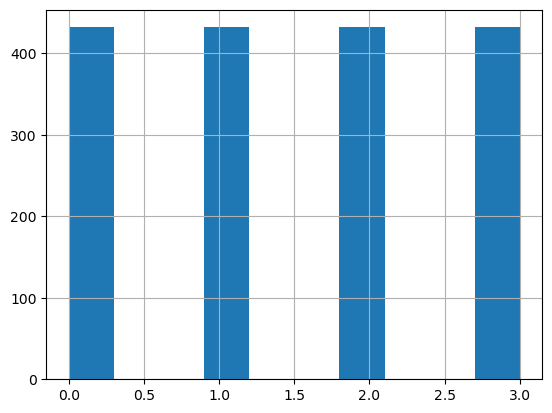

In [233]:
data['buying'].hist()

<Axes: >

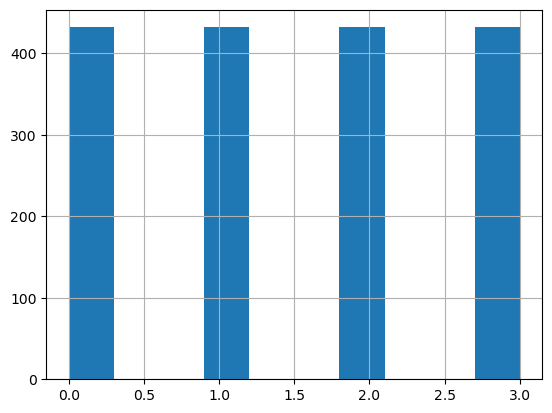

In [234]:
data['maint'].hist()



<Axes: xlabel='buying', ylabel='safety'>

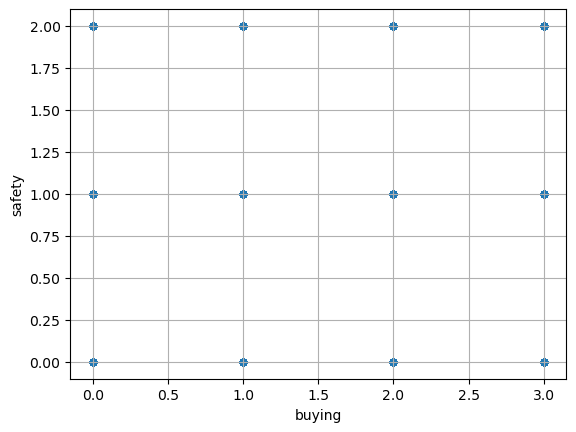

In [235]:
data.plot(kind='scatter', x='buying', y='safety', alpha=0.2, grid=True)

<Axes: >

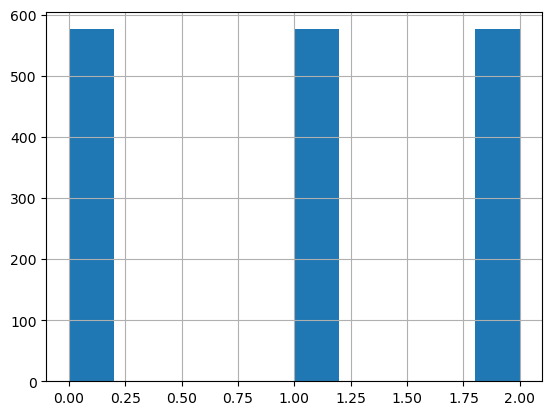

In [236]:
data['safety'].hist()

<Axes: >

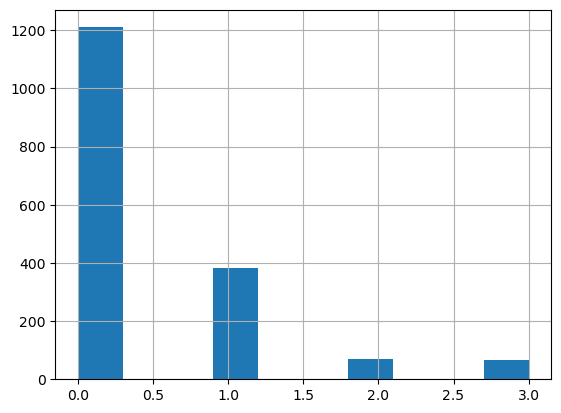

In [237]:
data['class'].hist()

In [238]:
X = data.drop('safety', axis=1)
Y = data['safety']

In [239]:
print(X)
print(Y)

      buying  maint  doors  persons  lug_boot  class
0          0      0    NaN      NaN         0      0
1          0      0    NaN      NaN         0      0
2          0      0    NaN      NaN         0      0
3          0      0    NaN      NaN         1      0
4          0      0    NaN      NaN         1      0
...      ...    ...    ...      ...       ...    ...
1723       3      3    0.0      0.0         1      2
1724       3      3    0.0      0.0         1      3
1725       3      3    0.0      0.0         2      0
1726       3      3    0.0      0.0         2      2
1727       3      3    0.0      0.0         2      3

[1728 rows x 6 columns]
0       0
1       1
2       2
3       0
4       1
       ..
1723    1
1724    2
1725    0
1726    1
1727    2
Name: safety, Length: 1728, dtype: int64


In [240]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [241]:
X.shape

(1728, 6)

In [242]:
X_test.shape

(519, 6)

In [243]:
X_train.shape

(1209, 6)

In [244]:
X_test

,buying,maint,doors,persons,lug_boot,class
599,1,1,NaN,NaN,1,0
1201,2,3,NaN,NaN,1,1
628,1,1,0.0,NaN,2,0
1498,3,1,0.0,NaN,1,1
1263,2,3,NaN,0.0,1,0
...,...,...,...,...,...,...
490,1,0,NaN,NaN,1,0
1277,2,3,0.0,NaN,2,0
287,0,2,NaN,NaN,2,1
1639,3,3,NaN,0.0,0,0


In [245]:
sc = StandardScaler()

In [246]:
sc.fit(X_train, Y_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [247]:
train_data = sc.predict

In [248]:
data = data.dropna(axis=0)

In [266]:
# RandomRandomForestClassifier
Rd = RandomForestClassifier()

In [281]:
Rd.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [282]:
train_data = Rd.predict(X_train)

In [283]:
accuracy_score = accuracy_score(Y_train, train_data)

In [284]:
print('Accuracy_training', accuracy_score)

Accuracy_training 0.6054590570719603


In [296]:

test_data = Rd.predict(X_test)

accuracy_score = accuracy_score(Y_test, test_data)

In [297]:
print('Accuracy_testing', accuracy_score)

Accuracy_testing 0.3930635838150289


In [298]:
# DecisiDecisionTreeClassifier
Dt = DecisionTreeClassifier()

In [272]:
Dt.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [273]:
train_data = Dt.predict(X_train)

In [274]:
training_accuracy = accuracy_score(Y_train, train_data)

In [275]:
print('training_accuracy', training_accuracy)

training_accuracy 0.6054590570719603


In [276]:
test_data = Dt.predict(X_test)

In [277]:
testing_accuracy = accuracy_score(Y_test,test_data)

In [279]:
print('Testing_accuracy', testing_accuracy)

Testing_accuracy 0.4161849710982659
